# GRAHSP vs JAXSEDFit: Chimera SED Comparison

This notebook combines the single-object JAXSEDFit flow from Notebook 11 with the original GRAHSP runner from Notebook 12. It fits the same Chimera object with both models, then plots the two SED decompositions side by side.


## Setup

Run this notebook from `jaxsedfit/notebooks`. The GRAHSP repository should be the parent checkout that contains both `jaxsedfit/` and `sampler/dualsampler.py`, and the DSPS SSP file should be available at `jaxsedfit/tempdata.h5`.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
import textwrap

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "jaxsedfit" / "src").is_dir() and (path / "sampler" / "dualsampler.py").is_file():
            return path
    raise RuntimeError("Could not find the GRAHSP repository root from the current directory.")


repo_root = find_repo_root()
jaxsedfit_root = repo_root / "jaxsedfit"
src_root = jaxsedfit_root / "src"
cigale_root = repo_root / "cigale"
sampler_script = repo_root / "sampler" / "dualsampler.py"
dsps_ssp_fn = jaxsedfit_root / "tempdata.h5"

for path in (src_root, cigale_root):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from jaxsedfit.benchmark import build_chimera_fit_config, load_chimera_benchmark_dataset, select_chimera_subset
from jaxsedfit.core import JAXSEDFit
from jaxsedfit.mplstyle import style_path
from jaxsedfit.plotting import _COMPONENT_STYLE, _median_site, _percentile_site, _to_display_flux_density

plt.style.use(style_path())

print("repo_root:", repo_root)
print("jaxsedfit_root:", jaxsedfit_root)
print("sampler:", sampler_script)
print("DSPS SSP:", dsps_ssp_fn)
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"

/home/nicho/miniconda3/envs/astro2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/nicho/miniconda3/envs/astro2/lib/python3.11/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /home/nicho/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


repo_root: /home/nicho/GRAHSP
jaxsedfit_root: /home/nicho/GRAHSP/jaxsedfit
sampler: /home/nicho/GRAHSP/sampler/dualsampler.py
DSPS SSP: /home/nicho/GRAHSP/jaxsedfit/tempdata.h5


## Pick A Chimera Object

Use the same default object as Notebook 11 so this comparison is directly tied to the current JAXSEDFit example. Change `target_object_id` to compare another row from the full Chimera benchmark.


In [2]:
dataset = load_chimera_benchmark_dataset(jaxsedfit_root)
subset = select_chimera_subset(dataset, jaxsedfit_root)

print(f"Loaded {len(dataset.rows)} full Chimera benchmark rows")
print(f"Loaded {len(subset)} deterministic tutorial subset rows")
print("Example object IDs:", [str(r["id"]) for r in subset[:5]])

target_object_id = "085343.83+341429.3_922277_0.01"

row = next((r for r in dataset.rows if str(r["id"]) == target_object_id), None)
if row is None:
    raise ValueError(f"target_object_id={target_object_id!r} was not found in the Chimera benchmark")

truth_logm = float(row["log_stellar_mass_truth"])
base_output_dir = jaxsedfit_root / "notebook_outputs" / "13_grahsp_vs_jaxsedfit_chimera_sed" / str(row["id"])
grahsp_output_dir = base_output_dir / "grahsp"
jaxsedfit_output_dir = base_output_dir / "jaxsedfit"
grahsp_output_dir.mkdir(parents=True, exist_ok=True)
jaxsedfit_output_dir.mkdir(parents=True, exist_ok=True)

print("object_id:", row["id"])
print("COSMOS ID:", row["ID_COSMOS"])
print("redshift:", row["redshift"])
print("chimera_QSO_weight:", row["chimera_QSO_weight"])
print("truth log stellar mass:", truth_logm)
print("output_dir:", base_output_dir)

[benchmark] Loading Chimera photometry from /home/nicho/GRAHSP/jaxsedfit/data/chimeras-2023-10-11/chimeras-grahsp.fits
[benchmark] Loading Chimera truth table from /home/nicho/GRAHSP/jaxsedfit/data/chimeras-2023-10-11/chimeras-fullinfo.fits
[benchmark] Joined 18168 Chimera rows
[benchmark] Loading deterministic subset from /home/nicho/GRAHSP/jaxsedfit/data/chimeras-2023-10-11/benchmark_subset_ids.txt
[benchmark] Selected 1 benchmark rows
Loaded 18168 full Chimera benchmark rows
Loaded 1 deterministic tutorial subset rows
Example object IDs: ['011521.37+311730.6_386291_0.0003']
object_id: 083152.12+144938.0_922124_0.0001
COSMOS ID: 922124
redshift: 0.39800000190734863
chimera_QSO_weight: 0.0001
truth log stellar mass: 10.1193
output_dir: /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/083152.12+144938.0_922124_0.0001


## Run JAXSEDFit

This mirrors Notebook 11. The default uses nested sampling because that is the active fit path there; lower `JAXSEDFit_NS_LIVE_POINTS` and `JAXSEDFit_NS_MAX_SAMPLES` for a quicker smoke test, or raise them for production-quality comparison.


In [3]:
RUN_JAXSEDFit = True
JAXSEDFit_FIT_METHOD = "ns"
JAXSEDFit_NS_LIVE_POINTS = 700
JAXSEDFit_NS_MAX_SAMPLES = 8000
JAXSEDFit_NS_DLOGZ = 10

cfg = build_chimera_fit_config(row, dsps_ssp_fn=str(dsps_ssp_fn))
cfg.inference.map_steps = 400
cfg.inference.learning_rate = 5e-3
cfg.inference.num_warmup = 400
cfg.inference.num_samples = 400
cfg.inference.method = JAXSEDFit_FIT_METHOD

print("Photometry-seeded prior centers:")
print("  log_stellar_mass:", cfg.prior_config.get("log_stellar_mass"))
print("  log_agn_amp:", cfg.prior_config.get("log_agn_amp"))
print("Host energy balance enabled:", cfg.galaxy.use_energy_balance)
print("Fixed AGN type:", cfg.agn.agn_type)

if RUN_JAXSEDFit:
    jaxsedfit_fitter = JAXSEDFit(cfg)
    jaxsedfit_fit_result = jaxsedfit_fitter.fit(
        prior_config=cfg.prior_config,
        dsps_ssp_fn=cfg.galaxy.dsps_ssp_fn,
        optax_steps=cfg.inference.map_steps,
        optax_lr=cfg.inference.learning_rate,
        nuts_warmup=cfg.inference.num_warmup,
        nuts_samples=cfg.inference.num_samples,
        nuts_chains=cfg.inference.num_chains,
        ns_live_points=JAXSEDFit_NS_LIVE_POINTS,
        ns_max_samples=JAXSEDFit_NS_MAX_SAMPLES,
        ns_dlogz=JAXSEDFit_NS_DLOGZ,
        plot_fig=False,
        save_fig=False,
        save_result=False,
        progress_bar=True,
    )
    jaxsedfit_pred = jaxsedfit_fitter.predict()
    jaxsedfit_samples = np.asarray(jaxsedfit_fitter.samples["log_stellar_mass"], dtype=float).reshape(-1)
    jaxsedfit_logm16, jaxsedfit_recovered_logm, jaxsedfit_logm84 = np.percentile(jaxsedfit_samples, [16.0, 50.0, 84.0])
    print("JAXSEDFit recovered log stellar mass:", jaxsedfit_recovered_logm)
    print("JAXSEDFit 16-84% interval:", (jaxsedfit_logm16, jaxsedfit_logm84))
    print("JAXSEDFit residual:", jaxsedfit_recovered_logm - truth_logm)
else:
    print("RUN_JAXSEDFit is False; set it to True to fit and generate the SED prediction.")

Photometry-seeded prior centers:
  log_stellar_mass: {'dist': 'student_t', 'loc': 10.0, 'scale': 2.0, 'df': 5.0}
  log_agn_amp: None
Host energy balance enabled: True
Fixed AGN type: 1


INFO:jaxns:Number of Markov-chains set to: 700


Creating initial state with 700 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(10., dtype=float64, weak_type=True), max_samples=Array(8050, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 350
Num likelihood evals: 48159
Efficiency: 0.014430311900884372
log(L) contour: -5027.291236240545
log(Z) est.: 23.88022028779983 +- 0.5457712218827391
log(Z | remaining) est.: 5059.261543180141 +- 0.9951372293267876
ESS: 1.4380436236464729

-------
Num samples: 700
Num likelihood evals: 97974
Efficiency: 0.009377093101138647
log(L) contour: -496.3696680394291
log(Z) est.: 23.479127030355205 +- 0.510983415056008
log(Z | remaining) est.: 528.3910800057238 +- 0.9665668159514801
ESS: 1.675806680160762

-------
Num samples: 1050
Num likelihoo

## Write GRAHSP Inputs

This is the same input-table conversion used in Notebook 12. GRAHSP expects CIGALE-style filter column names in mJy, with `IRAC1` and `IRAC2` instead of the JAXSEDFit internal names.


In [4]:
chimera_to_grahsp_filters = {
    "u_sdss": "u_sdss",
    "r_sdss": "r_sdss",
    "i_sdss": "i_sdss",
    "z_sdss": "z_sdss",
    "J_2mass": "J_2mass",
    "H_2mass": "H_2mass",
    "Ks_2mass": "Ks_2mass",
    "spitzer.irac.I1": "IRAC1",
    "spitzer.irac.I2": "IRAC2",
}

table_data = {
    "id": [str(row["id"])],
    "redshift": [float(row["redshift"])],
    "redshift_err": [0.0],
}
for chimera_name, grahsp_name in chimera_to_grahsp_filters.items():
    flux = float(row[chimera_name])
    err = float(row[f"{chimera_name}_err"])
    table_data[grahsp_name] = [flux if np.isfinite(flux) else -9999.0]
    table_data[f"{grahsp_name}_err"] = [err if np.isfinite(err) and err > 0 else -9999.0]

input_table = Table(table_data)
input_path = grahsp_output_dir / "chimera_object.ecsv"
input_table.write(input_path, format="ascii.ecsv", overwrite=True)

print("Wrote", input_path)
input_table

Wrote /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/083152.12+144938.0_922124_0.0001/grahsp/chimera_object.ecsv


id,redshift,redshift_err,u_sdss,u_sdss_err,r_sdss,r_sdss_err,i_sdss,i_sdss_err,z_sdss,z_sdss_err,J_2mass,J_2mass_err,H_2mass,H_2mass_err,Ks_2mass,Ks_2mass_err,IRAC1,IRAC1_err,IRAC2,IRAC2_err
str30,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
085343.83+341429.3_922277_0.01,0.3959999978542328,0.0,0.00200349441729486,5.043734927312471e-05,0.0027300019282847643,4.726519910036586e-05,0.0032537835650146008,5.100209091324359e-05,0.0053830924443900585,0.0001026430691126734,-9999.0,-9999.0,-9999.0,-9999.0,0.018186697736382484,0.0012650656281039119,0.036015961319208145,0.0003272662579547614,0.043377287685871124,0.0003299680829513818


## Build `pcigale.ini`

The GRAHSP configuration is copied from Notebook 12 so both notebooks use the same original-GRAHSP setup.


In [5]:
filters = list(chimera_to_grahsp_filters.values())
column_list = []
for name in filters:
    column_list.extend([name, f"{name}_err"])

pcigale_ini = f"""
data_file = {input_path}
column_list = {', '.join(column_list)}
creation_modules = sfh2exp, m2005, nebular, activate, activatelines, activategtorus, activatepl, activatebol, biattenuation, galdale2014, redshifting
analysis_method = pdf_analysis
cores = 1
cosmology = concordance

[statistics]
  exponent = 2
  systematics_width = 0.03
  variability_uncertainty = true
  attenuation_model_uncertainty = false
  Ly_break_uncertainty = false

[sed_creation_modules]
  [[sfh2exp]]
    tau_main = 500, 1500, 4000, 8000
    tau_burst = 50
    f_burst = 0.0, 0.01, 0.1
    age = 500, 1000, 3000, 6000, 9000, 12000
    burst_age = 20, 100
    sfr_0 = 1
    normalise = True

  [[m2005]]
    imf = 1
    metallicity = 0.02
    separation_age = 10

  [[nebular]]
    logU = -2.0
    zgas = 0.02
    ne = 100
    f_esc = 0.0
    f_dust = 0.0
    lines_width = 300
    emission = True

  [[activate]]
    fracAGN = -1

  [[activatelines]]
    AFeII = 5
    AGNtype = 1
    linewidth = 3000
    Alines = 1
    ABC = 0

  [[activategtorus]]
    fcov = 0.05, 0.2, 0.5
    Si = 0
    COOLlam = 17
    COOLwidth = 0.45
    HOTlam = 2.0
    HOTwidth = 0.5
    HOTfcov = 0.0, 0.5
    SiRatio = 0.29
    SiEmlam = 9841
    SiAbslam = 14224
    SiEmWidth = 1025.3
    SiAbsWidth = 1163.5

  [[activatepl]]
    plslope = -1.8
    plbendloc = 90
    plbendwidth = 0.5
    uvslope = 0
    cutoff = 10000

  [[activatebol]]

  [[biattenuation]]
    OPT_index = -1.2
    NIR_index = -3.0
    norm = 1.2
    lam_break = 1100
    E(B-V) = 0.001, 0.01, 0.1
    E(B-V)-AGN = 0.001, 0.03, 0.3, 1.0
    filters =

  [[galdale2014]]
    alpha = 2.0
    lam_max = -1

  [[redshifting]]
    redshift =

[analysis_configuration]
  analysed_variables = stellar.mass_total, stellar.mass_alive, sfh.sfr, sfh.sfr100Myrs, agn.lumBolBBB, agn.lumBolTOR, agn.fracAGNDale
  save_best_sed = False
  save_chi2 = False
  save_pdf = False
  lim_flag = False
  mock_flag = False
"""

config_path = grahsp_output_dir / "pcigale.ini"
config_path.write_text(textwrap.dedent(pcigale_ini).strip() + "\n")
print("Wrote", config_path)
print(config_path.read_text()[:1200])

Wrote /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/083152.12+144938.0_922124_0.0001/grahsp/pcigale.ini
data_file = /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/083152.12+144938.0_922124_0.0001/grahsp/chimera_object.ecsv
column_list = u_sdss, u_sdss_err, r_sdss, r_sdss_err, i_sdss, i_sdss_err, z_sdss, z_sdss_err, J_2mass, J_2mass_err, H_2mass, H_2mass_err, Ks_2mass, Ks_2mass_err, IRAC1, IRAC1_err, IRAC2, IRAC2_err
creation_modules = sfh2exp, m2005, nebular, activate, activatelines, activategtorus, activatepl, activatebol, biattenuation, galdale2014, redshifting
analysis_method = pdf_analysis
cores = 1
cosmology = concordance

[statistics]
  exponent = 2
  systematics_width = 0.03
  variability_uncertainty = true
  attenuation_model_uncertainty = false
  Ly_break_uncertainty = false

[sed_creation_modules]
  [[sfh2exp]]
    tau_main = 500, 1500, 4000, 8000
    tau_burst = 50
    f_burst = 0.0, 0.01, 0.1
    age = 500

## Run GRAHSP

This calls the original GRAHSP nested sampler. `MAKE_GRAHSP_PLOTS=True` is required for the `sed_mJy.csv.gz` product used in the side-by-side comparison.


In [6]:
RUN_GRAHSP = True
GRAHSP_NUM_LIVE_POINTS = 800
GRAHSP_NUM_POSTERIOR_SAMPLES = 3000
MAKE_GRAHSP_PLOTS = True

cmd = [
    sys.executable,
    str(sampler_script),
    "analyse",
    "--cores", "1",
    "--num-live-points", str(GRAHSP_NUM_LIVE_POINTS),
    "--num-posterior-samples", str(GRAHSP_NUM_POSTERIOR_SAMPLES),
    "--mass-max", "13",
]
if MAKE_GRAHSP_PLOTS:
    cmd.append("--plot")

env = os.environ.copy()
env["PYTHONPATH"] = os.pathsep.join([str(cigale_root), str(src_root), env.get("PYTHONPATH", "")])
env["OMP_NUM_THREADS"] = "1"
env["HDF5_USE_FILE_LOCKING"] = "FALSE"
env["MPLCONFIGDIR"] = str(grahsp_output_dir / "mplconfig")
env["CACHE_MAX"] = "5000"
(grahsp_output_dir / "mplconfig").mkdir(exist_ok=True)

print("Working directory:", grahsp_output_dir)
print("Command:", " ".join(cmd))

if RUN_GRAHSP:
    completed = subprocess.run(cmd, cwd=grahsp_output_dir, env=env, text=True, capture_output=True)
    print(completed.stdout[-6000:])
    if completed.returncode != 0:
        print(completed.stderr[-6000:])
        raise RuntimeError(f"GRAHSP failed with return code {completed.returncode}")
else:
    print("RUN_GRAHSP is False; set it to True to launch the fitter.")

Working directory: /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/083152.12+144938.0_922124_0.0001/grahsp
Command: /home/nicho/miniconda3/envs/astro/bin/python /home/nicho/GRAHSP/sampler/dualsampler.py analyse --cores 1 --num-live-points 800 --num-posterior-samples 3000 --mass-max 13 --plot
evals=7439/197737 eff=2.7898% N=800 
Z=42.3(48.06%) | Like=50.74..52.84 [50.7418..50.7424]*| it/evals=7440/197775 eff=2.7898% N=800 
Z=42.3(48.07%) | Like=50.74..52.84 [50.7433..50.7440]*| it/evals=7442/197873 eff=2.7894% N=800 
Z=42.3(48.08%) | Like=50.74..52.84 [50.7449..50.7476]*| it/evals=7444/197943 eff=2.7894% N=800 
Z=42.3(48.13%) | Like=50.75..52.84 [50.7476..50.7478]*| it/evals=7445/198025 eff=2.7887% N=800 
Z=42.3(48.19%) | Like=50.75..52.84 [50.7480..50.7498]*| it/evals=7447/198105 eff=2.7886% N=800 
Z=42.3(48.21%) | Like=50.75..52.84 [50.7518..50.7519]*| it/evals=7449/198194 eff=2.7884% N=800 
Z=42.3(48.29%) | Like=50.75..52.84 [50.7547..50.7597]*| it/ev

## Read GRAHSP Summary And SED Products

The mass summary is optional for the SED comparison, but it is useful context. The SED CSV is written only when GRAHSP is run with `--plot`.


In [7]:
summary_path = grahsp_output_dir / "chimera_object.ecsv_analysis_results.txt"
if not summary_path.is_file():
    raise FileNotFoundError(f"Missing GRAHSP summary file: {summary_path}")

grahsp_summary = Table.read(summary_path, format="ascii.commented_header", delimiter="\t")
grahsp_recovered_logm = float(grahsp_summary["log_stellar_mass_med"][0])
grahsp_logm_lo = float(grahsp_summary["log_stellar_mass_lo"][0])
grahsp_logm_hi = float(grahsp_summary["log_stellar_mass_hi"][0])

plot_dirs = sorted(grahsp_output_dir.glob("grahsp_*/plots"))
print("Plot directories:", plot_dirs)
if not plot_dirs:
    raise FileNotFoundError("No GRAHSP plot directory found. Re-run with MAKE_GRAHSP_PLOTS=True.")

grahsp_sed_path = plot_dirs[0] / "sed_mJy.csv.gz"
if not grahsp_sed_path.is_file():
    raise FileNotFoundError(f"Missing GRAHSP SED CSV: {grahsp_sed_path}")

grahsp_sed = Table.read(grahsp_sed_path, format="ascii.csv")

print("truth log stellar mass:", truth_logm)
print("GRAHSP recovered log stellar mass:", grahsp_recovered_logm)
print("GRAHSP 95.45% interval:", (grahsp_logm_lo, grahsp_logm_hi))
print("GRAHSP residual:", grahsp_recovered_logm - truth_logm)
print("GRAHSP SED columns:", grahsp_sed.colnames)

Plot directories: [PosixPath('/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/083152.12+144938.0_922124_0.0001/grahsp/grahsp_083152.12+144938.0_922124_0.0001_varV1_maxgal13/plots')]
truth log stellar mass: 10.1193
GRAHSP recovered log stellar mass: 7.10144
GRAHSP 95.45% interval: (5.20129, 8.24225)
GRAHSP residual: -3.0178600000000007
GRAHSP SED columns: ['wavelength', 'AGN disk', 'AGN disk_errup', 'AGN disk_errlo', 'AGN torus', 'AGN torus_errup', 'AGN torus_errlo', 'AGN lines', 'AGN lines_errup', 'AGN lines_errlo', 'Stellar (attenuated)', 'Stellar (attenuated)_errup', 'Stellar (attenuated)_errlo', 'Nebular emission', 'Nebular emission_errup', 'Nebular emission_errlo', 'Dust', 'Dust_errup', 'Dust_errlo', 'total', 'total_errup', 'total_errlo']


## Side-By-Side SED Comparison

Both panels use observed-frame wavelength and mJy. The JAXSEDFit panel is drawn from the posterior predictive spectrum; the GRAHSP panel is drawn from `sed_mJy.csv.gz`.


Wrote /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/13_grahsp_vs_jaxsedfit_chimera_sed/083152.12+144938.0_922124_0.0001/grahsp_vs_jaxsedfit_sed.png


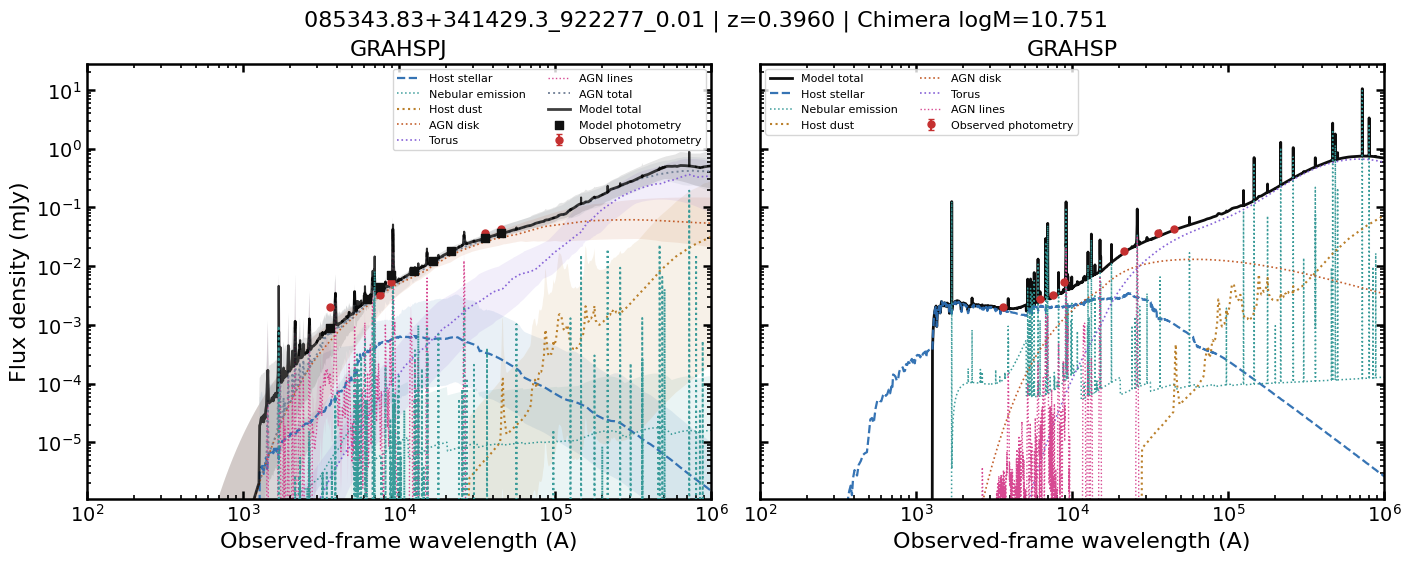

In [8]:
from grahspj.plotting import _median_site_sum, _percentile_site_sum


def _positive_component(y):
    y = np.asarray(y, dtype=float)
    return np.isfinite(y) & (y > 0.0)


def plot_jaxsedfit_panel(ax, fitter, pred):
    obs_wave_a = _median_site(pred, "obs_wave")
    phot_wave_a = np.asarray([flt.effective_wavelength for flt in fitter.context.filters], dtype=float)
    obs_flux = np.asarray(fitter.config.photometry.fluxes, dtype=float)
    obs_err = np.asarray(fitter.config.photometry.errors, dtype=float)
    model_flux = _median_site(pred, "pred_fluxes")

    labels_seen = set()
    all_y = [obs_flux, model_flux]

    for keys, label, color, lw in _COMPONENT_STYLE:
        key_list = keys if isinstance(keys, (list, tuple, set)) else [keys]
        key_tuple = tuple(key_list)

        if not any(key in pred for key in key_tuple):
            continue

        component = _to_display_flux_density(obs_wave_a, _median_site_sum(pred, key_tuple))
        if not np.any(_positive_component(component)):
            continue

        lo = _to_display_flux_density(obs_wave_a, _percentile_site_sum(pred, key_tuple, 16.0))
        hi = _to_display_flux_density(obs_wave_a, _percentile_site_sum(pred, key_tuple, 84.0))

        all_y.extend([component, lo, hi])
        plot_label = label if label not in labels_seen else "_nolegend_"
        labels_seen.add(label)

        if np.any(_positive_component(lo) & _positive_component(hi)):
            ax.fill_between(
                obs_wave_a,
                np.clip(np.minimum(lo, hi), 1e-300, None),
                np.clip(np.maximum(lo, hi), 1e-300, None),
                color=color,
                alpha=0.10,
                linewidth=0.0,
            )

        ls = "-" if "total_obs_sed" in key_tuple else ("--" if "host_obs_sed" in key_tuple else ":")
        alpha = 0.75 if "total_obs_sed" in key_tuple else 0.95
        ax.plot(obs_wave_a, component, color=color, lw=lw, ls=ls, alpha=alpha, label=plot_label)

    ax.errorbar(phot_wave_a, obs_flux, yerr=obs_err, fmt="o", color="#c53030", ms=5, capsize=2, label="Observed photometry", zorder=5)
    ax.scatter(phot_wave_a, model_flux, color="#111111", marker="s", s=28, label="Model photometry", zorder=6)
    ax.set_title("JAXSEDFit")
    return all_y


def plot_grahsp_panel(ax, sed_table, row):
    wave_um = np.asarray(sed_table["wavelength"], dtype=float)
    wave_a = wave_um * 1.0e4
    all_y = []

    column_styles = [
        ("total", "Model total", "#000000", 2.0, "-"),
        ("Stellar (attenuated)", "Host stellar", "#2b6cb0", 1.6, "--"),
        ("Nebular emission", "Nebular emission", "#319795", 1.1, ":"),
        ("Dust", "Host dust", "#b7791f", 1.5, ":"),
        ("AGN disk", "AGN disk", "#c05621", 1.2, ":"),
        ("AGN torus", "Torus", "#805ad5", 1.2, ":"),
        ("FeII", "Fe II", "#2f855a", 1.0, ":"),
        ("AGN lines", "AGN lines", "#d53f8c", 1.0, ":"),
        ("Balmer continuum", "Balmer cont.", "#dd6b20", 1.0, ":"),
    ]

    for col, label, color, lw, ls in column_styles:
        if col not in sed_table.colnames:
            continue

        y = np.asarray(sed_table[col], dtype=float)
        if not np.any(_positive_component(y)):
            continue

        all_y.append(y)
        ax.plot(wave_a, y, color=color, lw=lw, ls=ls, alpha=0.95, label=label)

    phot_wave_a = np.asarray([flt.effective_wavelength for flt in jaxsedfit_fitter.context.filters], dtype=float)
    obs_flux = np.asarray([float(row[name]) for name in chimera_to_grahsp_filters], dtype=float)
    obs_err = np.asarray([float(row[f"{name}_err"]) for name in chimera_to_grahsp_filters], dtype=float)

    all_y.extend([obs_flux, obs_err])

    ax.errorbar(
        phot_wave_a,
        obs_flux,
        yerr=obs_err,
        fmt="o",
        color="#c53030",
        ms=5,
        capsize=2,
        label="Observed photometry",
        zorder=5,
    )
    ax.set_title("GRAHSP")
    return all_y


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
    sharex=True,
    sharey=True,
    layout="constrained",
)

y_parts = []
y_parts.extend(plot_jaxsedfit_panel(axes[0], jaxsedfit_fitter, jaxsedfit_pred))
y_parts.extend(plot_grahsp_panel(axes[1], grahsp_sed, row))

for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Observed-frame wavelength (A)")
    ax.legend(fontsize=8, ncol=2, loc="best")

axes[0].set_ylabel("Flux density (mJy)")

finite_y = np.concatenate([np.ravel(np.asarray(y, dtype=float)) for y in y_parts])
finite_y = finite_y[np.isfinite(finite_y) & (finite_y > 0.0)]

if finite_y.size:
    ymax = float(np.nanmax(finite_y))
    ymin = (
        float(np.nanmin(finite_y[finite_y >= ymax * 1e-7]))
        if np.any(finite_y >= ymax * 1e-7)
        else float(np.nanmin(finite_y))
    )

    for ax in axes:
        ax.set_ylim(ymin * 0.7, ymax * 1.8)
        ax.set_xlim(1e2, 1e6)

fig.suptitle(f"{row['id']} | z={float(row['redshift']):.4f} | Chimera logM={truth_logm:.3f}")
comparison_path = base_output_dir / "grahsp_vs_jaxsedfit_sed.png"
fig.savefig(comparison_path, dpi=180)

print("Wrote", comparison_path)
plt.show()

## Normalized Host Stellar Shape Diagnostic

This compares the host stellar continuum shapes after normalizing each model at rest-frame 5100 Angstrom. GRAHSPJ uses `host_rest_sed` directly. GRAHSP is read from `Stellar (attenuated)` in `sed_mJy.csv.gz`, converted from observed-frame `F_nu` to an `F_lambda`-proportional shape, shifted to rest-frame wavelength, and normalized at the same wavelength.


GRAHSPJ normalization at 5100 A: 1.9581065239085824e+31
GRAHSP F_lambda-shape normalization at 5100 A: 3.936982860027575e-11
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/13_grahsp_vs_grahspj_chimera_sed/085343.83+341429.3_922277_0.01/host_stellar_rest_shape_comparison.png


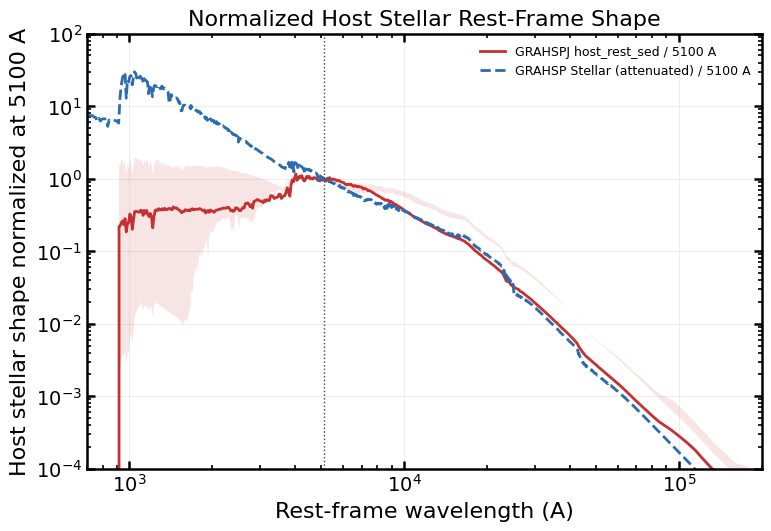

In [9]:
def _positive_norm_curve(wave, y, norm_wave=5100.0):
    wave = np.asarray(wave, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(wave)
    wave = wave[order]
    y = y[order]
    finite = np.isfinite(wave) & np.isfinite(y) & (wave > 0.0) & (y > 0.0)
    if finite.sum() < 3:
        return wave, np.full_like(wave, np.nan), np.nan
    norm = np.interp(norm_wave, wave[finite], y[finite], left=np.nan, right=np.nan)
    if not np.isfinite(norm) or norm <= 0.0:
        nearest = np.nanargmin(np.abs(wave[finite] - norm_wave))
        norm = y[finite][nearest]
    return wave, y / norm, norm


def _grahsp_mjy_to_flambda_shape(wave_obs_a, flux_mjy):
    # Constants cancel after normalization; this preserves the F_lambda shape.
    wave_obs_a = np.asarray(wave_obs_a, dtype=float)
    flux_mjy = np.asarray(flux_mjy, dtype=float)
    return flux_mjy / np.maximum(wave_obs_a, 1.0e-30) ** 2


norm_wave_a = 5100.0
z_object = float(row["redshift"])

# GRAHSPJ: native rest-frame L_lambda host stellar component.
grahspj_rest_wave = np.nanmedian(np.asarray(grahspj_pred["rest_wave"], dtype=float), axis=0)
grahspj_host_rest = np.nanmedian(np.asarray(grahspj_pred["host_rest_sed"], dtype=float), axis=0)
grahspj_host_lo = np.nanpercentile(np.asarray(grahspj_pred["host_rest_sed"], dtype=float), 16.0, axis=0)
grahspj_host_hi = np.nanpercentile(np.asarray(grahspj_pred["host_rest_sed"], dtype=float), 84.0, axis=0)

grahspj_wave, grahspj_host_normed, grahspj_norm = _positive_norm_curve(grahspj_rest_wave, grahspj_host_rest, norm_wave_a)
_, grahspj_host_lo_normed, _ = _positive_norm_curve(grahspj_rest_wave, grahspj_host_lo, norm_wave_a)
_, grahspj_host_hi_normed, _ = _positive_norm_curve(grahspj_rest_wave, grahspj_host_hi, norm_wave_a)

# GRAHSP: sed_mJy.csv.gz wavelengths are observed-frame; convert F_nu-like mJy to F_lambda shape.
grahsp_wave_obs_a = np.asarray(grahsp_sed["wavelength"], dtype=float) * 1.0e4
grahsp_wave_rest_a = grahsp_wave_obs_a / (1.0 + z_object)
grahsp_stellar_flambda_shape = _grahsp_mjy_to_flambda_shape(
    grahsp_wave_obs_a,
    np.asarray(grahsp_sed["Stellar (attenuated)"], dtype=float),
)
grahsp_wave, grahsp_host_normed, grahsp_norm = _positive_norm_curve(
    grahsp_wave_rest_a,
    grahsp_stellar_flambda_shape,
    norm_wave_a,
)

fig, ax = plt.subplots(figsize=(7.6, 5.2), constrained_layout=True)
ax.plot(
    grahspj_wave,
    grahspj_host_normed,
    color="#c53030",
    lw=2.0,
    label="GRAHSPJ host_rest_sed / 5100 A",
)
if np.any(np.isfinite(grahspj_host_lo_normed) & np.isfinite(grahspj_host_hi_normed)):
    ax.fill_between(
        grahspj_wave,
        np.clip(np.minimum(grahspj_host_lo_normed, grahspj_host_hi_normed), 1.0e-12, None),
        np.clip(np.maximum(grahspj_host_lo_normed, grahspj_host_hi_normed), 1.0e-12, None),
        color="#c53030",
        alpha=0.12,
        linewidth=0.0,
    )
ax.plot(
    grahsp_wave,
    grahsp_host_normed,
    color="#2b6cb0",
    lw=2.0,
    ls="--",
    label="GRAHSP Stellar (attenuated) / 5100 A",
)
ax.axvline(norm_wave_a, color="0.25", lw=1.0, ls=":")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(7.0e2, 2.0e5)
ax.set_ylim(1.0e-4, 1.0e2)
ax.set_xlabel("Rest-frame wavelength (A)")
ax.set_ylabel("Host stellar shape normalized at 5100 A")
ax.set_title("Normalized Host Stellar Rest-Frame Shape")
ax.grid(alpha=0.22)
ax.legend(frameon=False, fontsize=9)

host_shape_path = base_output_dir / "host_stellar_rest_shape_comparison.png"
fig.savefig(host_shape_path, dpi=180)
print("GRAHSPJ normalization at 5100 A:", grahspj_norm)
print("GRAHSP F_lambda-shape normalization at 5100 A:", grahsp_norm)
print("Wrote", host_shape_path)
plt.show()



## Normalized AGN Disk Shape Diagnostic

This repeats the 5100 Angstrom rest-frame shape comparison for the AGN disk continuum. GRAHSPJ uses `disk_rest_sed` directly. GRAHSP is read from `AGN disk` in `sed_mJy.csv.gz`, converted from observed-frame `F_nu` to an `F_lambda`-proportional shape, shifted to rest-frame wavelength, and normalized at 5100 Angstrom.


GRAHSPJ disk normalization at 5100 A: 1.242970752787305e+32
GRAHSP disk F_lambda-shape normalization at 5100 A: 1.2465127563472245e-11
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/13_grahsp_vs_grahspj_chimera_sed/085343.83+341429.3_922277_0.01/agn_disk_rest_shape_comparison.png


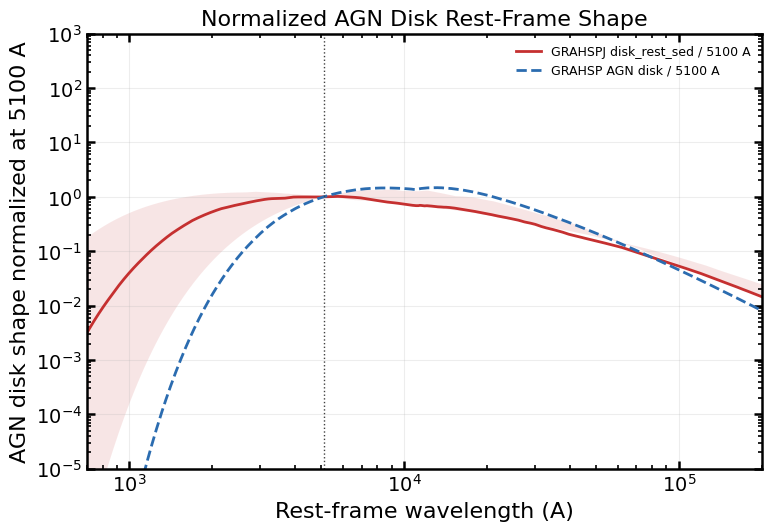

In [10]:
# Reuse _positive_norm_curve and _grahsp_mjy_to_flambda_shape from the host-shape diagnostic if present.
try:
    _positive_norm_curve
    _grahsp_mjy_to_flambda_shape
except NameError:
    def _positive_norm_curve(wave, y, norm_wave=5100.0):
        wave = np.asarray(wave, dtype=float)
        y = np.asarray(y, dtype=float)
        order = np.argsort(wave)
        wave = wave[order]
        y = y[order]
        finite = np.isfinite(wave) & np.isfinite(y) & (wave > 0.0) & (y > 0.0)
        if finite.sum() < 3:
            return wave, np.full_like(wave, np.nan), np.nan
        norm = np.interp(norm_wave, wave[finite], y[finite], left=np.nan, right=np.nan)
        if not np.isfinite(norm) or norm <= 0.0:
            nearest = np.nanargmin(np.abs(wave[finite] - norm_wave))
            norm = y[finite][nearest]
        return wave, y / norm, norm


    def _grahsp_mjy_to_flambda_shape(wave_obs_a, flux_mjy):
        # Constants cancel after normalization; this preserves the F_lambda shape.
        wave_obs_a = np.asarray(wave_obs_a, dtype=float)
        flux_mjy = np.asarray(flux_mjy, dtype=float)
        return flux_mjy / np.maximum(wave_obs_a, 1.0e-30) ** 2


norm_wave_a = 5100.0
z_object = float(row["redshift"])

# GRAHSPJ: native rest-frame L_lambda AGN disk component.
grahspj_rest_wave = np.nanmedian(np.asarray(grahspj_pred["rest_wave"], dtype=float), axis=0)
grahspj_disk_rest = np.nanmedian(np.asarray(grahspj_pred["disk_rest_sed"], dtype=float), axis=0)
grahspj_disk_lo = np.nanpercentile(np.asarray(grahspj_pred["disk_rest_sed"], dtype=float), 16.0, axis=0)
grahspj_disk_hi = np.nanpercentile(np.asarray(grahspj_pred["disk_rest_sed"], dtype=float), 84.0, axis=0)

grahspj_wave, grahspj_disk_normed, grahspj_disk_norm = _positive_norm_curve(grahspj_rest_wave, grahspj_disk_rest, norm_wave_a)
_, grahspj_disk_lo_normed, _ = _positive_norm_curve(grahspj_rest_wave, grahspj_disk_lo, norm_wave_a)
_, grahspj_disk_hi_normed, _ = _positive_norm_curve(grahspj_rest_wave, grahspj_disk_hi, norm_wave_a)

# GRAHSP: sed_mJy.csv.gz wavelengths are observed-frame; convert F_nu-like mJy to F_lambda shape.
grahsp_wave_obs_a = np.asarray(grahsp_sed["wavelength"], dtype=float) * 1.0e4
grahsp_wave_rest_a = grahsp_wave_obs_a / (1.0 + z_object)
grahsp_disk_flambda_shape = _grahsp_mjy_to_flambda_shape(
    grahsp_wave_obs_a,
    np.asarray(grahsp_sed["AGN disk"], dtype=float),
)
grahsp_wave, grahsp_disk_normed, grahsp_disk_norm = _positive_norm_curve(
    grahsp_wave_rest_a,
    grahsp_disk_flambda_shape,
    norm_wave_a,
)

fig, ax = plt.subplots(figsize=(7.6, 5.2), constrained_layout=True)
ax.plot(
    grahspj_wave,
    grahspj_disk_normed,
    color="#c53030",
    lw=2.0,
    label="GRAHSPJ disk_rest_sed / 5100 A",
)
if np.any(np.isfinite(grahspj_disk_lo_normed) & np.isfinite(grahspj_disk_hi_normed)):
    ax.fill_between(
        grahspj_wave,
        np.clip(np.minimum(grahspj_disk_lo_normed, grahspj_disk_hi_normed), 1.0e-12, None),
        np.clip(np.maximum(grahspj_disk_lo_normed, grahspj_disk_hi_normed), 1.0e-12, None),
        color="#c53030",
        alpha=0.12,
        linewidth=0.0,
    )
ax.plot(
    grahsp_wave,
    grahsp_disk_normed,
    color="#2b6cb0",
    lw=2.0,
    ls="--",
    label="GRAHSP AGN disk / 5100 A",
)
ax.axvline(norm_wave_a, color="0.25", lw=1.0, ls=":")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(7.0e2, 2.0e5)
ax.set_ylim(1.0e-5, 1.0e3)
ax.set_xlabel("Rest-frame wavelength (A)")
ax.set_ylabel("AGN disk shape normalized at 5100 A")
ax.set_title("Normalized AGN Disk Rest-Frame Shape")
ax.grid(alpha=0.22)
ax.legend(frameon=False, fontsize=9)

agn_disk_shape_path = base_output_dir / "agn_disk_rest_shape_comparison.png"
fig.savefig(agn_disk_shape_path, dpi=180)
print("GRAHSPJ disk normalization at 5100 A:", grahspj_disk_norm)
print("GRAHSP disk F_lambda-shape normalization at 5100 A:", grahsp_disk_norm)
print("Wrote", agn_disk_shape_path)
plt.show()



## Mass Context

This last panel is not the main comparison, but it helps interpret whether a SED difference is accompanied by a stellar-mass difference.


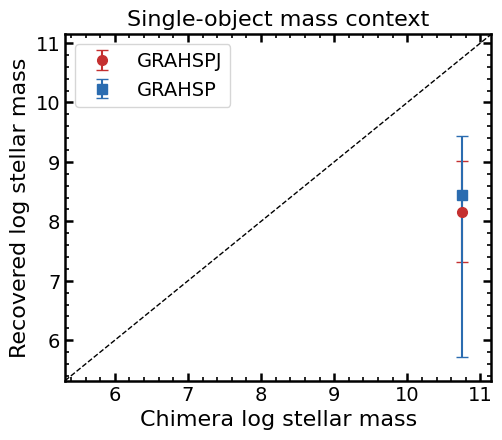

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.errorbar(
    [truth_logm],
    [jaxsedfit_recovered_logm],
    yerr=[[jaxsedfit_recovered_logm - jaxsedfit_logm16], [jaxsedfit_logm84 - jaxsedfit_recovered_logm]],
    fmt="o",
    color="#c53030",
    capsize=4,
    ms=7,
    label="JAXSEDFit",
)
ax.errorbar(
    [truth_logm],
    [grahsp_recovered_logm],
    yerr=[[grahsp_recovered_logm - grahsp_logm_lo], [grahsp_logm_hi - grahsp_recovered_logm]],
    fmt="s",
    color="#2b6cb0",
    capsize=4,
    ms=7,
    label="GRAHSP",
)
lims = [
    min(truth_logm, jaxsedfit_logm16, grahsp_logm_lo) - 0.4,
    max(truth_logm, jaxsedfit_logm84, grahsp_logm_hi) + 0.4,
]
ax.plot(lims, lims, color="black", ls="--", lw=1.0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Chimera log stellar mass")
ax.set_ylabel("Recovered log stellar mass")
ax.legend()
ax.set_title("Single-object mass context")
plt.show()